In [4]:
import numpy
import matplotlib.pyplot as plt
import csv

In [27]:
def get_name(name):
    match name:
        case 'baseline_customer_psql': return 'Baseline (PrivateSQL)'
        case 'baseline_customer': return 'Baseline (Ours)'
        case name: return f'Policy {name[-1]}'

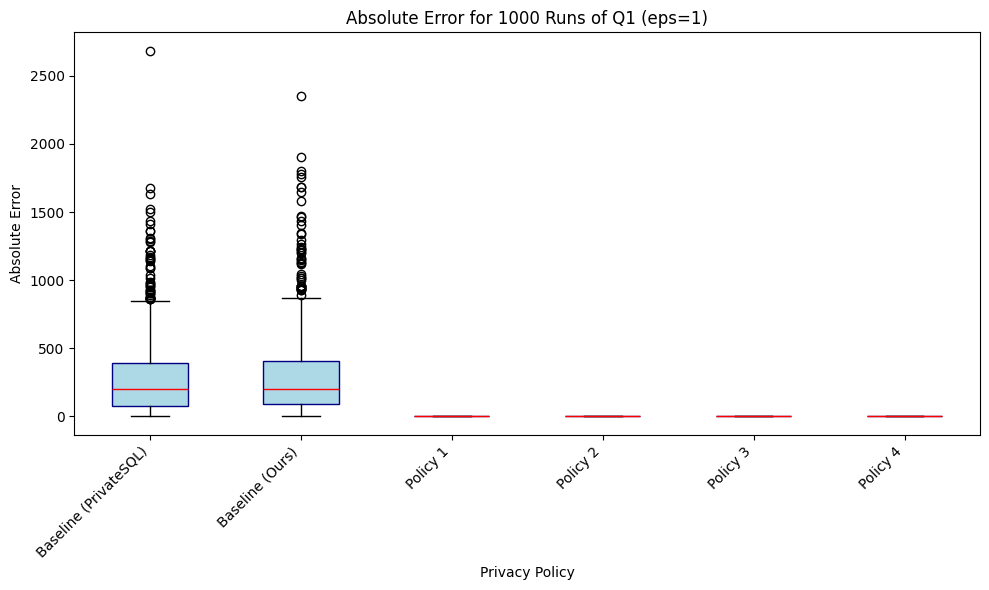

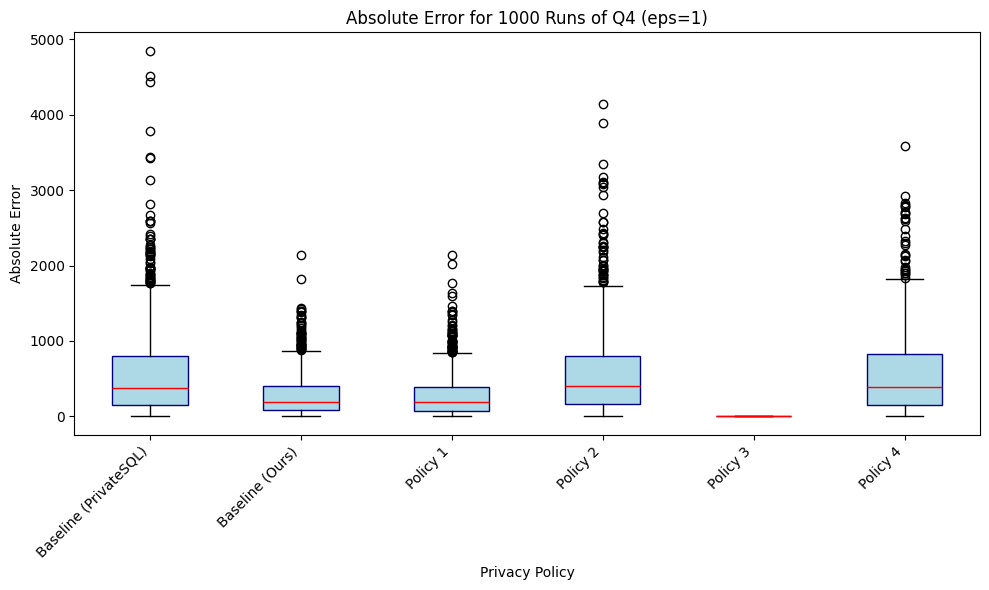

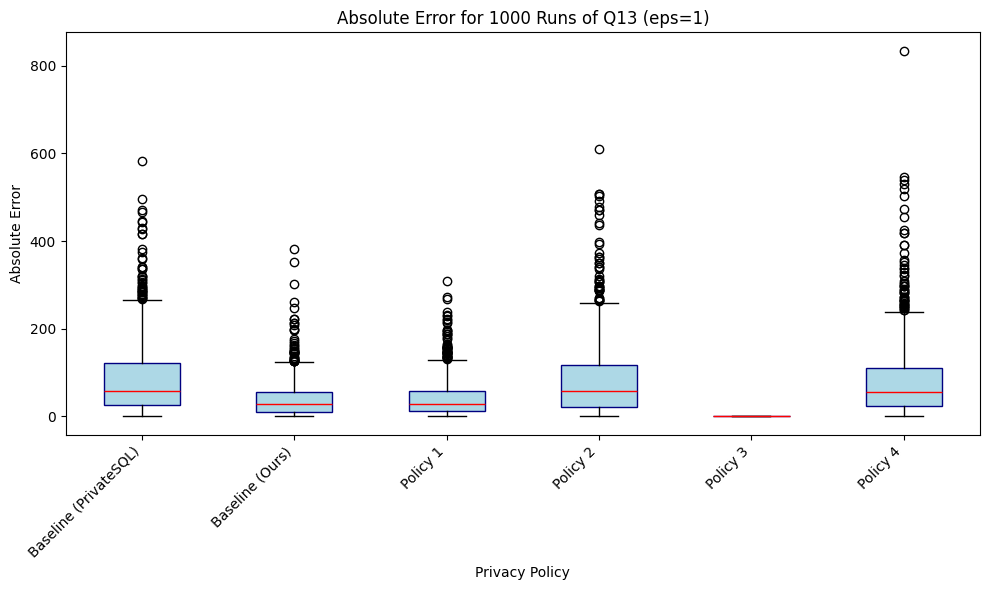

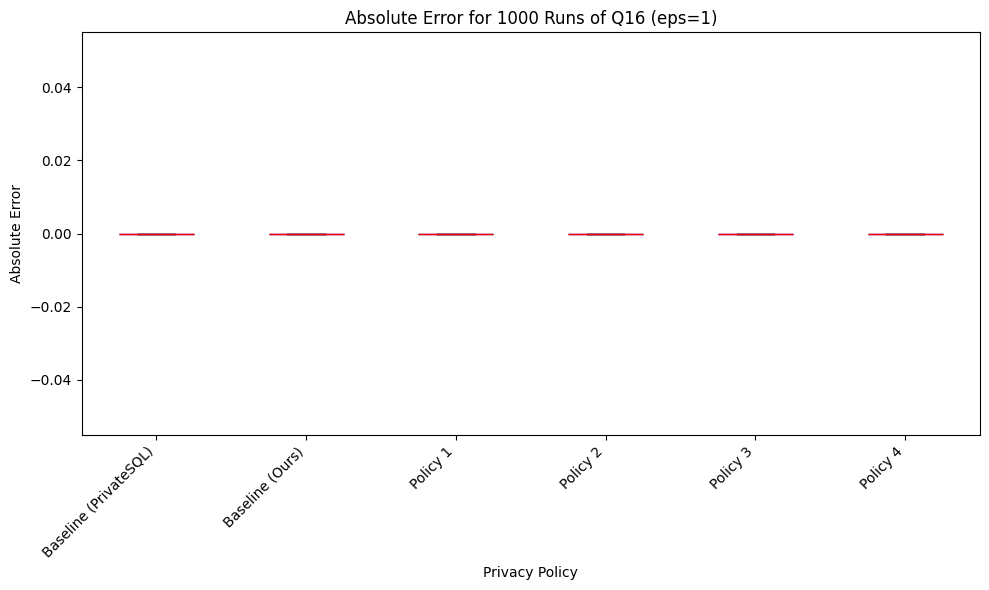

In [28]:
queries = [1, 4, 13, 16]

for query in queries:
    file = f'tpch_q{query}.csv'
    names = []
    data = []
    
    with open(file, newline='') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            names.append(get_name(row[0]))
            values = np.array(row[1:], dtype=float)
            data.append(values)
    
    data = np.array(data)
    
    plt.figure(figsize=(10, 6))
    plt.boxplot(
        data.T,
        tick_labels=names,
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", color="navy"),
        medianprops=dict(color="red")
    )
    
    plt.title(f'Absolute Error for 1000 Runs of Q{query} (eps=1)')
    plt.xlabel("Privacy Policy")
    plt.ylabel("Absolute Error")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    plt.show()